Importing necessary Libraries


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv('patient.csv')  #read csv file

In [3]:
df.shape  #shape of dataset

(4212, 14)

contains 4212 rows and 14 columns

In [4]:
df.head() #give  top 5 rows

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


In [5]:
df.tail() #give bottom 5 rows

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
4207,4208,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4208,4209,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4209,4210,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4210,4211,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated
4211,4212,NaN,NaN,Korea,NaN,NaN,NaN,NaN,NaN,NaN,2020-03-01,NaN,NaN,isolated


In [6]:
df.describe() #gives statistical information it includes only numerical columns

,id,birth_year,infection_order,infected_by,contact_number
count,4212.000000,292.000000,35.000000,62.000000,32.000000
mean,2106.500000,1973.184932,2.257143,330.741935,96.843750
std,1216.043996,17.336573,1.357828,458.786744,224.669522
min,1.000000,1937.000000,1.000000,3.000000,0.000000
25%,1053.750000,1959.000000,1.000000,29.250000,2.750000
50%,2106.500000,1972.000000,2.000000,126.000000,16.500000
75%,3159.250000,1987.000000,3.000000,372.000000,69.750000
max,4212.000000,2018.000000,6.000000,1768.000000,1160.000000


In [7]:
df.isnull().sum()

,0
id,0
sex,3894
birth_year,3920
country,0
region,3907
group,4136
infection_reason,4082
infection_order,4177
infected_by,4150
contact_number,4180


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB


In [9]:
numeric_cols=df.select_dtypes(include='number').columns
categorical_cols=df.select_dtypes(include='object').columns
print(numeric_cols)
print(categorical_cols)

Index(['id', 'birth_year', 'infection_order', 'infected_by', 'contact_number'], dtype='object')
Index(['sex', 'country', 'region', 'group', 'infection_reason',
       'confirmed_date', 'released_date', 'deceased_date', 'state'],
      dtype='object')


In [10]:
for col in numeric_cols:
    df[col]=df[col].fillna(df[col].mean())

In [11]:
for col in categorical_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [12]:
df.isnull().sum()

,0
id,0
sex,0
birth_year,0
country,0
region,0
group,0
infection_reason,0
infection_order,0
infected_by,0
contact_number,0


In [13]:
date_cols=['confirmed_date','released_date','deceased_date']
for col in date_cols:
    df[col]=pd.to_datetime(df[col],errors='coerce')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                4212 non-null   int64         
 1   sex               4212 non-null   object        
 2   birth_year        4212 non-null   float64       
 3   country           4212 non-null   object        
 4   region            4212 non-null   object        
 5   group             4212 non-null   object        
 6   infection_reason  4212 non-null   object        
 7   infection_order   4212 non-null   float64       
 8   infected_by       4212 non-null   float64       
 9   contact_number    4212 non-null   float64       
 10  confirmed_date    4212 non-null   datetime64[ns]
 11  released_date     4212 non-null   datetime64[ns]
 12  deceased_date     4212 non-null   datetime64[ns]
 13  state             4212 non-null   object        
dtypes: datetime64[ns](3), fl

**1.who is getting effected?**

In [15]:
df['sex'].value_counts()

,count
sex,
female,4057
male,155


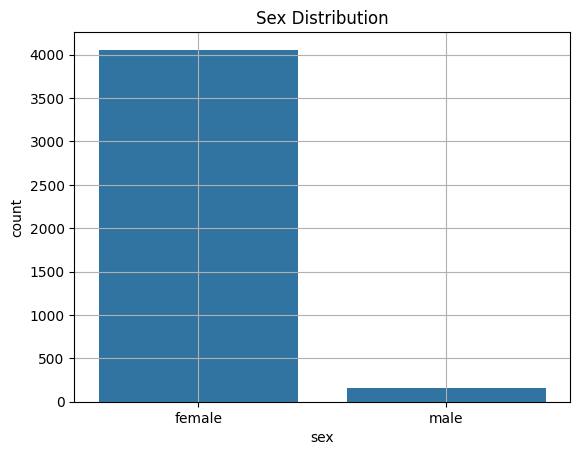

In [16]:
sns.countplot(x='sex',data=df)
plt.title('Sex Distribution')
plt.grid(True)
plt.show()


Females are mostly effected by COVID-19

In [17]:
df['age']=2026-df['birth_year']
df['age'].describe()

,age
count,4212.000000
mean,52.815068
std,4.557400
min,8.000000
25%,52.815068
50%,52.815068
75%,52.815068
max,89.000000


Text(0.5, 1.0, 'Age Distribution')

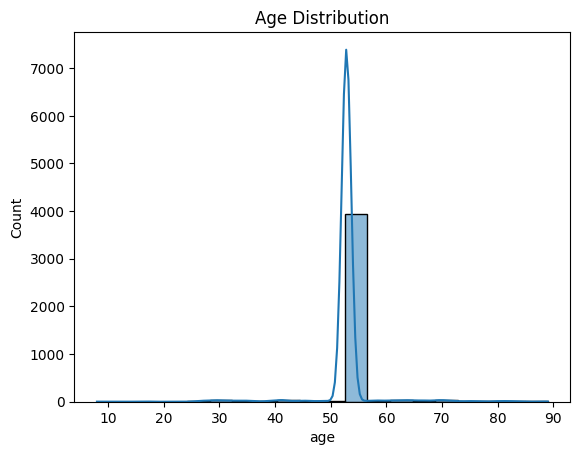

In [18]:
sns.histplot(df['age'],bins=20,kde=True)
plt.title('Age Distribution')


So from above histogram it is clear that people around 50-60 yeras of age suffered more

In [19]:
df['country'].value_counts()

,count
country,
Korea,4203
China,8
Mongolia,1


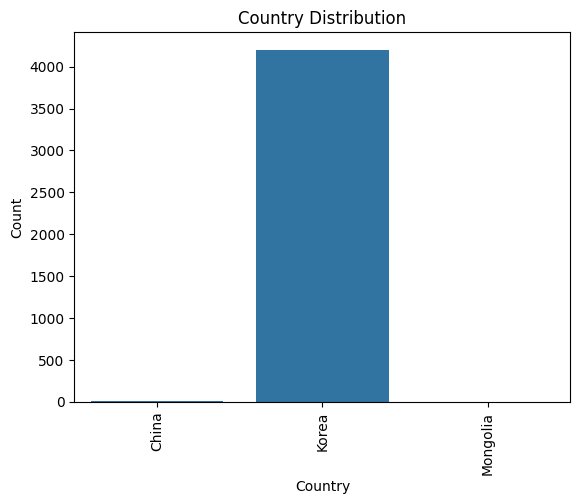

In [20]:
sns.countplot(x='country', data=df)
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Country Distribution')
plt.show()

People from korea has higher count

**2.How are infections spreading?**

In [21]:
df['infection_reason'].value_counts()

,count
infection_reason,
contact with patient,4148
visit to Daegu,40
visit to Wuhan,8
pilgrimage to Israel,6
contact with patient in Singapore,2
residence in Wuhan,2
visit to Thailand,2
contact with patient in Japan,1
visit to China,1


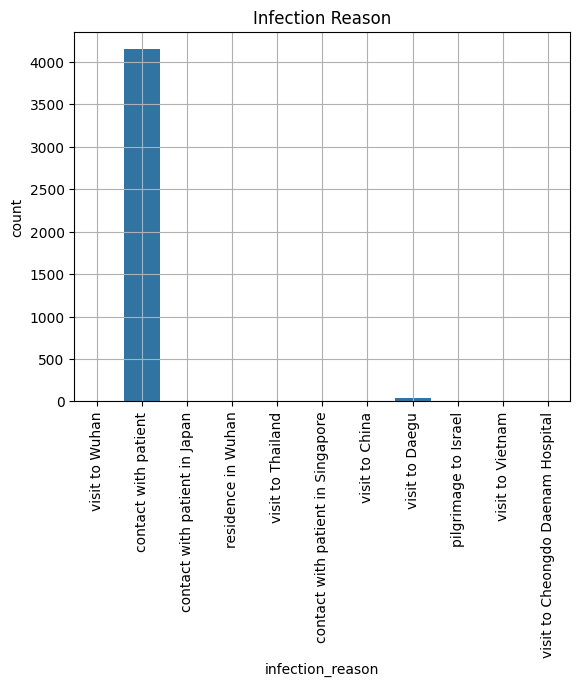

In [22]:
sns.countplot(x='infection_reason',data=df)
plt.title('Infection Reason')
plt.grid(True)
plt.xticks(rotation=90)
plt.show()

infection spreads more when contact with person

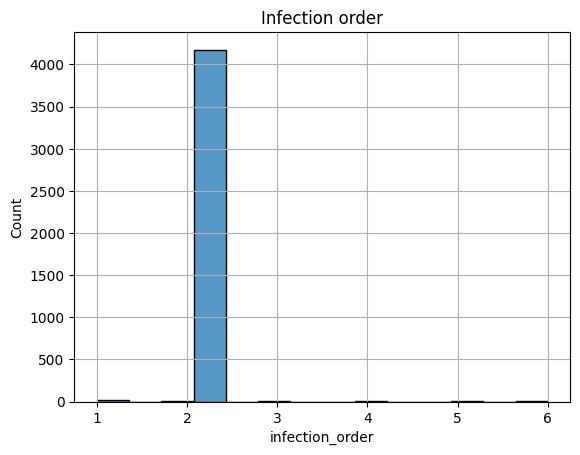

In [23]:
sns.histplot(x='infection_order',data=df)
plt.title('Infection order')
plt.grid(True)
plt.show()

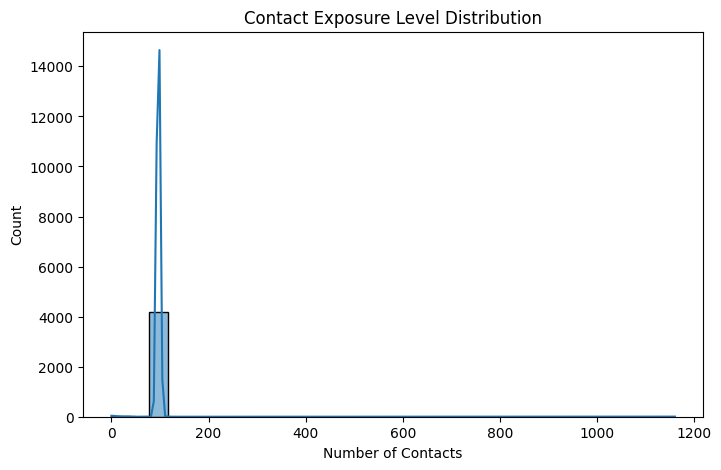

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['contact_number'], bins=30, kde=True)
plt.title("Contact Exposure Level Distribution")
plt.xlabel("Number of Contacts")
plt.ylabel("Count")
plt.show()


Higher contact numbers indicate greater exposure risk and faster spread potential.

**3.what are the recovery trends?**

In [25]:
df['recovery_days']=(df['confirmed_date']-df['released_date']).dt.days
df['recovery_days'].describe()

,recovery_days
count,4212.000000
mean,8.099003
std,3.451111
min,-24.000000
25%,7.000000
50%,9.000000
75%,11.000000
max,11.000000


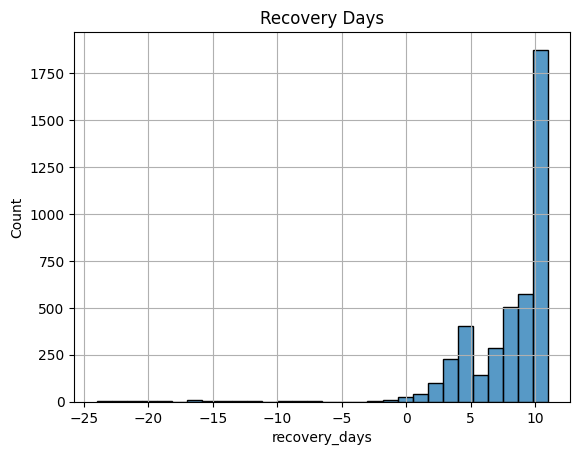

In [26]:
sns.histplot(x='recovery_days',bins=30,data=df)
plt.title('Recovery Days')
plt.grid(True)
plt.show()

minimum of 5-10 days are required to recover from COVID-19

**4.which regions are most impacted?**

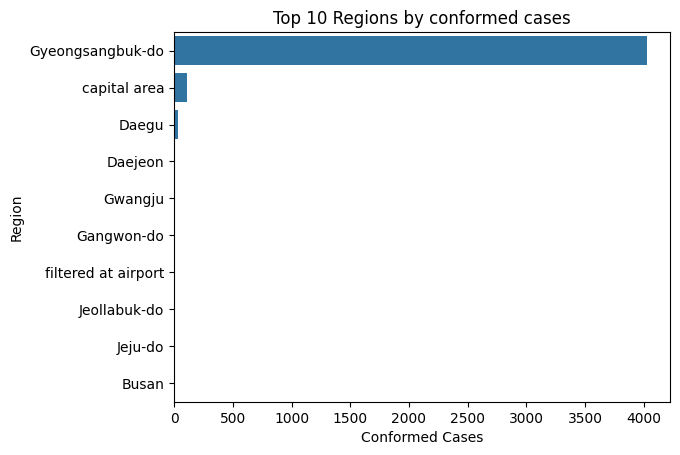

In [27]:
sns.countplot(y='region',data=df,order=df['region'].value_counts().head(10).index)
plt.title('Top 10 Regions by conformed cases')
plt.xlabel('Conformed Cases')
plt.ylabel('Region')
plt.show()

Gyeongsangbuk-do region is affected more based on conformed cases followed by capital area and least affected region is Busan region

In [28]:
released_df = df[df['state'] == 'released']
released_by_region = released_df['region'].value_counts()
released_by_region.head(10)


,count
region,
capital area,16
filtered at airport,4
Gwangju,3
Gyeongsangbuk-do,2
Daegu,2
Jeollabuk-do,1


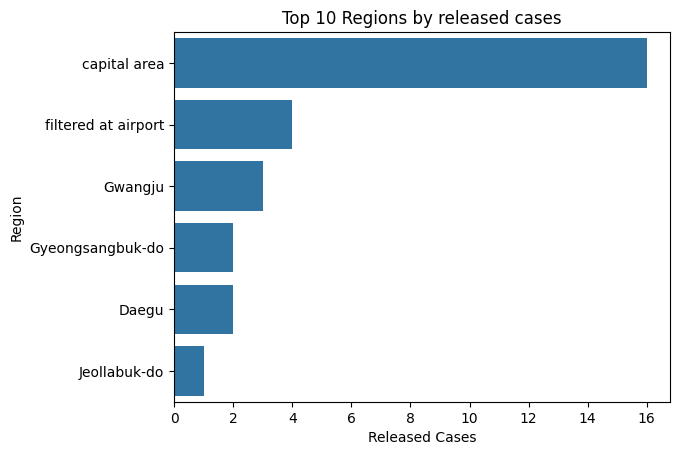

In [29]:
sns.countplot(y='region',data=released_df,order=released_by_region.head(10).index)
plt.title('Top 10 Regions by released cases')
plt.xlabel('Released Cases')
plt.ylabel('Region')
plt.show()


captial city has released the most and least relased is jeollabuk-do

**5.Factors influenincing recovery time**

In [30]:
numeric_cols

Index(['id', 'birth_year', 'infection_order', 'infected_by', 'contact_number'], dtype='object')

In [31]:
corr_df = df[['age', 'contact_number','infection_order', 'recovery_days']].corr()
corr_df


,age,contact_number,infection_order,recovery_days
age,1.000000,0.052334,0.16569,0.017821
contact_number,0.052334,1.000000,0.00132,0.059309
infection_order,0.165690,0.001320,1.00000,0.136000
recovery_days,0.017821,0.059309,0.13600,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

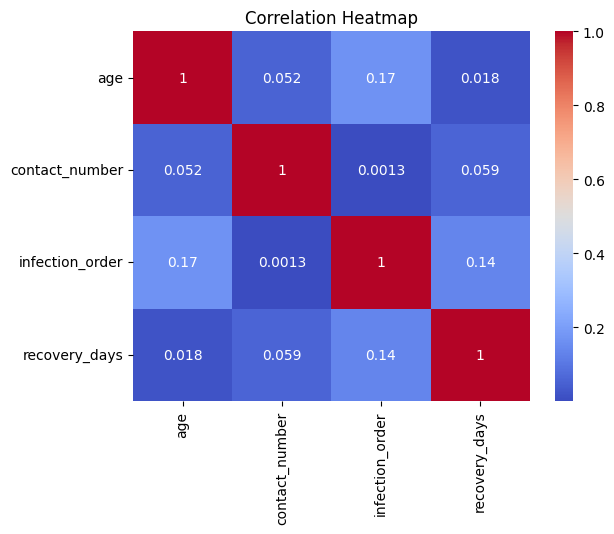

In [32]:
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Factors influenicing recovery time is infection order followed by contact_number and age

**Regression model to predict days to recover**

In [33]:
model_df = df[['age', 'contact_number', 'infection_order', 'recovery_days']].dropna()

In [34]:
X = model_df[['age', 'contact_number', 'infection_order']]
y = model_df['recovery_days']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [37]:
y_pred=model.predict(X_test)